# Differential decay rate

`transporttk.localprobe.LocalProbe` models a single STM-like tip weakly coupled to one site of a
bulk sample. `get_kappa` extracts a decay-constant/transparency-scaling diagnostic
$\kappa=d\log G/d\log T$: how steeply the conductance scales with the probe-sample coupling
$T$. Away from the gap, single-particle tunneling conductance scales linearly with the coupling
($G\propto T$, so $\kappa=1$); deep inside the gap, where transport can only proceed via Andreev
reflection (a two-electron, Cooper-pair-transferring process), conductance instead scales
quadratically ($G\propto T^2$, so $\kappa=2$) -- the well-known signature used experimentally to
distinguish Andreev-dominated sub-gap transport from ordinary single-particle tunneling.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures

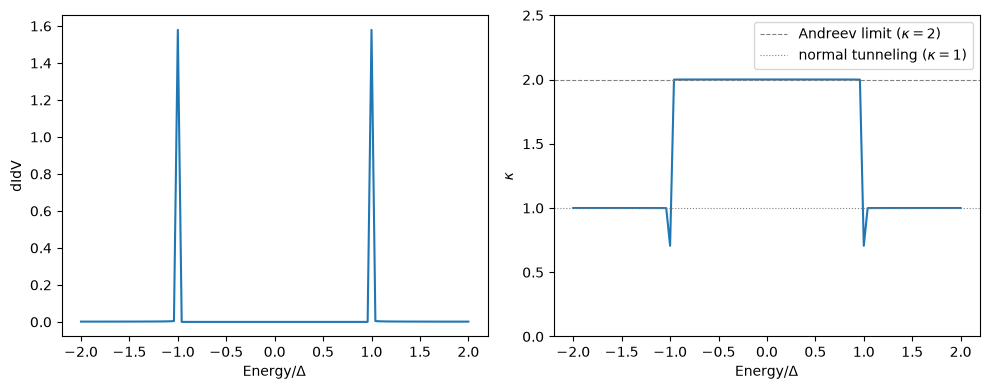

In [2]:
from pyqula.heterostructures import LocalProbe

g = geometry.chain()
h = g.get_hamiltonian()
h.shift_fermi(1.)
D = 0.1 # superconducting gap
h.add_swave(D)
lp = LocalProbe(h,delta=1e-8)
lp.T = 2e-2 # reference (small, tunneling) transparency
es = np.linspace(-2*D,2*D,101)
ts = [lp.didv(energy=e) for e in es]
ks = [lp.get_kappa(energy=e) for e in es] # decay rate kappa = d log G / d log T

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(es/D,ts) ; axs[0].set_xlabel("Energy/$\Delta$") ; axs[0].set_ylabel("dIdV")
axs[1].plot(es/D,ks) ; axs[1].set_xlabel("Energy/$\Delta$") ; axs[1].set_ylabel("$\kappa$")
axs[1].axhline(2.0,c="grey",ls="--",lw=0.8,label="Andreev limit ($\kappa=2$)")
axs[1].axhline(1.0,c="grey",ls=":",lw=0.8,label="normal tunneling ($\kappa=1$)")
axs[1].set_ylim([0,2.5]) ; axs[1].legend()
plt.tight_layout()
plt.show()